# Predicting Temperature in London

![tower_bridge](tower_bridge.jpeg)

#### This project was done in January, 2026.

## 📖 The Background
As the climate changes, predicting the weather becomes ever more important for businesses. Since the weather depends on a lot of different factors, you will want to run a lot of experiments to determine what the best approach is to predict the weather. In this project, you will run experiments for different regression models predicting the mean temperature, using a combination of `sklearn` and `MLflow`.


## 💾 Dataset Summary
The data is stored in `london_weather.csv`, which contains the following variables:

| Variable              | Description                                             | Data Type |
|-----------------------|---------------------------------------------------------|-------------|
| **date**              | recorded date of measurement                            | Integer |
| **cloud_cover**       | cloud cover measurement in oktas                        | Float |
| **sunshine**          | sunshine measurement in hours (hrs)                     | Float |
| **global_radiation**  | irradiance measurement in Watt per square meter (W/m2)  | Float |
| **max_temp**          | maximum temperature recorded in degrees Celsius (°C)    | Float |
| **mean_temp**         | mean temperature in degrees Celsius (°C)                | Float |
| **min_temp**          | minimum temperature recorded in degrees Celsius (°C)    | Float |
| **precipitation**     | precipitation measurement in millimeters (mm)           | Float |
| **pressure**          | pressure measurement in Pascals (Pa)                    | Float |
| **snow_depth**        | snow depth measurement in centimeters (cm)              | Float |



# Objectives
Use machine learning to predict the mean temperature in London, England, logging root mean squared error (RMSE) metrics using `mlflow`.
- Build a model to predict `"mean_temp"` with a RMSE of 3 or less.
- Use MLflow to log any models that are trained, their hyperparameters, & respective RMSE scores (ensuring you include `"rmse"` as part of the metric name).
- Search all `mlflow` runs & store the results as a variable called `experiment_results`.

# Summary of Findings & Recommendations
This project utilizes machine learning techniques from the `mlflow` module to examine weather & climate data in London from 1979-2020. More specifically, statistical analyses & regression models were built to evaluate the data & cast predictions as the temperatures in London, United Kingdom.  
Three different algorithms were involved in the analysis: linear regression, decision tree regression, & random forest regression. Prediction & error metrics were utilized to evaluate the predictive accuracy of each model in order to determine which algorithm produced the most precise predictions. Multiple `mlflow` runs were executed for each method to get an overview as to the general accuracy & to avoid volatile models in terms of predictive power.

In this project, there were two main sections.


### Analysis I - Exploratory Data Analysis, Cleaning
The dataset was imported & evaluated to determine what preprocessing steps, if any, were necessary before thorough analyses could be done. Of the ten variables, only one had more than 36 missing values (there were 15,341 data points in the dataset). These variables were later imputed (see **Analysis II**) if they were among the feature variables involved in the modeling process.

A general evaluation of the primary variable of interest ('mean_temp') was conducted. Between 1979-2020, the average daily temperature ranged between -7.6 & 29.0 °C. When evaluated over time, the average annual temperature in London increased by roughly 0.0647 degrees Celsius during this period. There is clearly a positive trend in terms of the average temperature in London over time, one that is likely to continue in the near future.

Statistical analyses, including concepts like correlation, were performed to quantify relationships between other variables & the mean temperature. The variables with the most significant correlation with the average temperature included 'sunshine' & 'global_radiation' (correlations of 0.40 & 0.64 respectively), which makes logical sense. In other words, the more sunlight or radiation that London received generally corresponded to higher temperatures. This relationship can be observed by the fact that temperatures are usually higher during the day when the Sun is up than during the night.


### Analysis II - Modeling
With a general understanding of the dataset & the primary variable, machine learning algorithms were assembled. Given that the target variable is numerical, regression models were used. Specifically, linear, decision tree, & random forest regression models were utilized in this section.

Given that a primary goal of this project was to build a model with a small RMSE, a smaller set of feature variables was utilized as opposed to including all nine of the other variables. Specifically, these features were the 'month', 'cloud_cover', 'sunshine', 'precipitation', 'pressure', & 'global_radiation'.
- The 'max_temp' & 'min_temp' have very high, positive correlations with 'mean_temp'; however, these were not included because they are measuring & describing the same general quantity as the average temperature & are therefore redundant in the modeling process.
An imputer was used to impute missing values in these variables (except for month which had no missing values) & a scaler was applied to the data to standardize it, helping to ensure that the different variables applied an equal amount of input when predicting the mean temperature.

Using functions from the `mlflow` module, nine total runs were completed, three for each algorithm. For the non-linear ones, the `max_depth` parameter was altered (1, 2, 10). Of these nine models, only one returned a RMSE less than 3.0; the **random forest** model with a `max_depth` of 10 had a RMSE of about **2.848**.
- In comparing the three MLFlow runs, a higher `max_depth` value was definitely more beneficial in terms of producing a more accurate model, particularly for the decision tree & random forest models. The linear regression models had the same RMSE in all three runs because linear regression models don't use such a hyperparameter.
- The three linear regression models had the lowest average RMSE (~ 3.757), just barely better than that of the random forest models (~ 3.760). The decision tree models had the highest average RMSE; ~ 3.873.


#### Recommendations
Given the results, the random forest models can be considered to produce the best fits for this dataset given the specific feature variables included, particularly those with a larger `max_depth`.

Further analysis & experimentation could explore additional hyperparater tuning options as well as altering what variables were used (or not used) in predicting the average temperature. It is likely that including the variables with the strongest correlation with 'mean_temp' will produce more accurate models because they change in relation to one another. In this case, those variables are 'sunshine' & 'global_radiation.'

------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------

# Import packages, data

In [2]:
#import packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Analysis I - Exploratory Data Analysis, Cleaning
After importing the data, it should be evaluated to check for inconsistencies & to get a basic understanding of the many variables. This should give an idea as to what kind of preprocessing steps need to be taken to prepare the data for more extensive, valid analyses.

In [3]:
#import data
orig_df = pd.read_csv("london_weather.csv")

#inspect data
display(orig_df.sample(3))
display(orig_df.info())

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
6763,19970708,5.0,7.4,239.0,26.3,21.5,15.4,0.8,102500.0,0.0
13033,20140907,2.0,5.1,144.0,22.5,17.6,13.5,0.0,101590.0,0.0
12612,20130713,1.0,12.1,301.0,29.8,22.9,14.3,0.0,102390.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


None

There are 15,341 data points & ten variables eight of which have missing values--only one variable has more than 36 missing values ('snow_depth', 1,441). For these other seven variables, it is fine to drop them given how few data points they account for.  
Regardless, they, particularly the missing values in the 'snow_depth' variable, should be imputed ideally with the median or mean. To determine which metric would be better, the distributions of these variables would need to be evaluated to check if they're skewed or not. If there is a meaningful skew, than the median would be the better imputation metric. Otherwise, the mean would be satisfactory. That being said, it is more appropriate to drop the 36 observations with missing 'mean_temp' values because this is the target variable in this project.
- Imputing/removing missing values will be done later in the **Analysis II - Modeling** section.

The data types are reasonable except for the 'date' variable which should be converted to datetime formats. Moreover, if time/date variables will be used as feature variables, it could be useful to break the date down into years & months.

In [4]:
#make a copy of the original data
df = orig_df.copy()

#convert 'date's to datetimes, extract year & month
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
df["year"] = df["date"].dt.year
df['month'] = df['date'].dt.month

#obtain yearly, monthly avg's pertaining to metrics quantifying weather
weather_metrics = ['cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 
                   'pressure', 'snow_depth']
weather_avg_per_month = df.groupby(['year', 'month'], as_index=False)[weather_metrics].mean()

Before creating predictive models, it will be useful to inspect the data for patterns & relationships, particularly the target variable ('mean_temp'). Some notes are listed below.
- The data spans 1979-01-01 to 2020-12-31, or about 42 years.
- The average temperature on any given day in London during this time period was somewhere between -7.6 & 29.0 °C.

Building some visuals can be effective in this process to get a basic understanding of the variables involved, particularly the target variable; 'mean_temp.'

In [23]:
#Retrieve summary statistics of target variable -- 'mean_temp'
display(df['mean_temp'].describe())

#Find average increase per year, per day
#Obtain the average annual temperature for the first/last years of data
df_79_20_avgs = df[df.year.isin([1979,2020])].groupby('year', as_index=False)[weather_metrics].mean()
#Find the average increase in mean, annual temp across the 42-year period
yr_avg_temp_change = round((df_79_20_avgs['mean_temp'][1] - df_79_20_avgs['mean_temp'][0])/42, 4)
display(f"The average annual temperature in London increased by roughly {yr_avg_temp_change} degrees Celsius between 1979-2020.")
#Divide by 365 to get daily increase in avg temp
display(f"The average annual temperature in London increased by roughly {round(yr_avg_temp_change/365, 5)} degrees Celsius between 1979-2020.")


count    15305.000000
mean        11.475511
std          5.729709
min         -7.600000
25%          7.000000
50%         11.400000
75%         16.000000
max         29.000000
Name: mean_temp, dtype: float64

'The average annual temperature in London increased by roughly 0.0647 degrees Celsius between 1979-2020.'

'The average annual temperature in London increased by roughly 0.00018 degrees Celsius between 1979-2020.'

C:\Users\elija\AppData\Local\Temp\ipykernel_10692\455648265.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax1 = sns.lineplot(x="year", y="mean_temp", data=weather_avg_per_month, ci=None, marker='.')


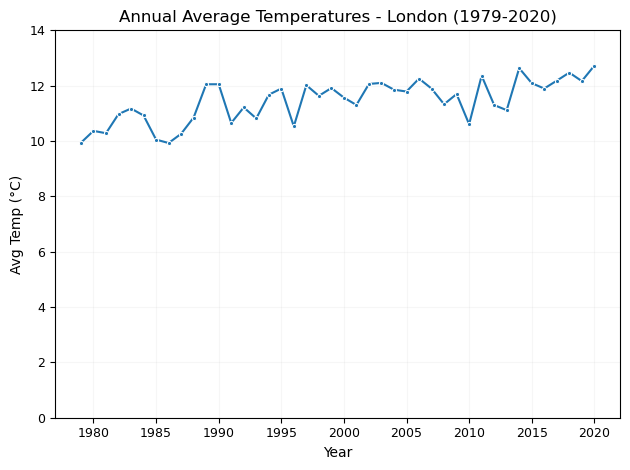

In [9]:
#Visualize the average annual temperature in London

#plot avg yearly temp's
ax1 = sns.lineplot(x="year", y="mean_temp", data=weather_avg_per_month, ci=None, marker='.')
#edit plot details
plt.title('Annual Average Temperatures - London (1979-2020)')
plt.xlabel('Year')
plt.xticks(ticks=range(1980,2021,5), fontsize=9)
plt.ylabel('Avg Temp (°C)')
#adjust the vertical range to avoid false impressions
plt.yticks(ticks=range(0,15,2), fontsize=9)
plt.grid(axis='both', alpha=0.1)
plt.tight_layout();

The figure above illustrates the average yearly temperature in London between 1979-2020. It is pretty clear that there is an increasing trend in temperature over the 40-odd-year period. More exactly, the average annual temperature in London increased by roughly 0.0647 degrees Celsius between 1979-2020. On a daily basis, the average temperature increased by about 0.00018 degrees. Given this, it is reasonable to hypothesize that temperatures will continue to increase steadily in the near future.

A correlation heatmap can be produced to quantify the strength of relationships between numerical variables. This can give an idea as to which feature variables may be the most relevant in predicting average temperature.

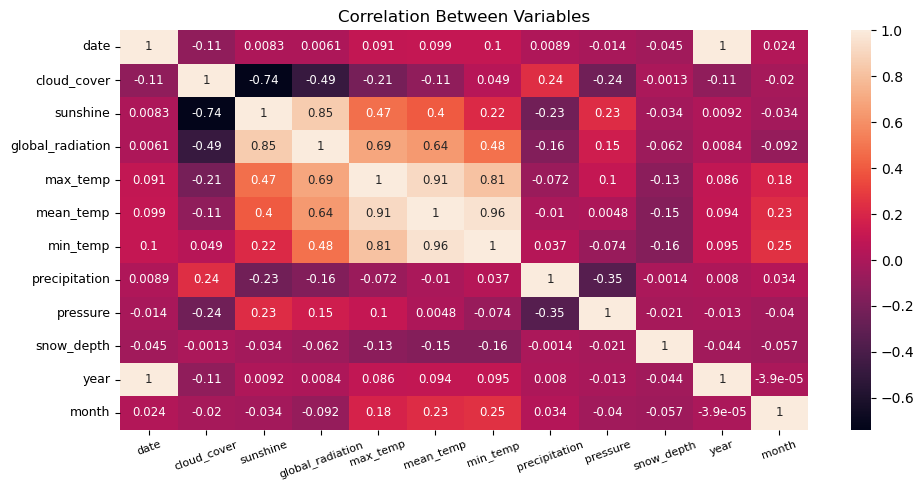

In [6]:
#make a heatmap to quantify the relationship between numerical variables
plt.figure(figsize=(10,5))
ax2 = sns.heatmap(df.corr(), annot=True, annot_kws={'fontsize':8.5})
#edit plot details
plt.title('Correlation Between Variables')
plt.xticks(rotation=20, fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout();

The heatmap above quantifies relationships between the variables in the dataset. Note that correlation coefficients with magnitudes less than 0.30 are generally considered negligible. In other words, such variables don't have a meaningful relationship with each other. Moreover, correlation does not imply causation but rather that variables change in relation to others.  
With that being said, some of the most notable relationships observed here include:
- 'sunshine' & 'cloud_cover' | -0.74
- 'global_radiation' & 'cloud_cover' | -0.49
- 'global_radiation' & 'sunshine' | 0.85

In regard to the target variable ('mean_temp'), it has the following relationships that are considered meaningful.
- 'mean_temp' & 'sunshine' | 0.40
- 'mean_temp' & 'global_radiation' | 0.64

Based on these values, the average temperature in London during this time period generally increased in accordance with the amount of sunshine & global radiation. More specifically, as London saw more amounts of sunshine & global radiation, the average temperature also increased. Additional analyses could investigate how these two variables changed over time.

# Analysis II - Modeling
With a basic understanding of the dataset & the target variable ('mean_temp'), machine-learning algorithms can be assembled.

With so many variables & data points in the dataset, it is important to not oversaturate the predictive models because it could result in a model that overfits--a model that performs strongly on the training data but poorly on unseen data. Given that a primary goal in this project is to create a model with a small root mean square error (RMSE), such models should be avoided.  
Furthermore, to create a model that has better predictive power, particularly on unseen data, it might be more appropriate to avoid using all of the other variables in the dataset. Those that correlate the most with the target variable ('mean_temp') might produce a more accurate model. Based on the heatmap above, such variables include 'sunshine' & 'global_radiation'. To add more diversity, a couple of other variables could still be included regardless of their correlation coefficient; e.g. 'precipitation', 'pressure'.
- Ultimately, the feature variables might have to be altered depending on the final results & error terms. Some combinations of variables might yield lower error terms. This is something further experimentation could explore.

Additionally, given the various ranges of values across the many variables in the dataset, this might cause certain variables to impact the model more than others. To avoid this, the data should be standardized using a `StandardScaler()` object.  
Recall that observations with missing 'mean_temp' values need to be removed, & some imputing needs to be done for other variables with missing values which will be used as features in the models. This can be done using a `SimpleImputer()` object.

Given that the target variable is numerical, this is a regression problem. As such, models like `LinearRegression()`, `DecisionTreeRegressor()`, `RandomForestRegressor()`, & others could be used. In this case, the aforementioned three methods will be utilized. As such, the main parameter that will be tuned in this process is the `max_depth` because it is common amongst the latter two methods. No parameter was tuned in the linear-regression models.

When it comes to evaluating the models, the root mean square error (RMSE) will be utilized. The smaller this metric, the more accurate the predictions of a model.

In the following models, the variables selected to be features include: 'sunshine', 'global_radiation', 'month', 'cloud_cover', 'precipitation', & 'pressure'. The variables 'min_temp' & 'max_temp' had very strong correlation with the target variable, but they were not included here because they are describing/measuring the same general quantity.  
A test size of 25% was used for the evaluation of the models.

In [7]:
#select feature, target variables, drop missing values from 'mean_temp'
feature_vars = ['month', 'cloud_cover', 'sunshine', 'precipitation', 'pressure', 'global_radiation']
df_model = df.dropna(subset=['mean_temp'])

#subset feature, target data
X = df_model[feature_vars]    
y = df_model['mean_temp']
    
#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

For missing values in the feature variables, which are all numeric apart from 'month' which has no missing values, they were imputed using the average of each variable. A standard scaler object was applied to normalize the ranges of the variables.

In [8]:
#impute missing values of relevant variables using the mean
imputer = SimpleImputer(strategy="mean")
#fit, transform the training data
X_train = imputer.fit_transform(X_train)
#transform the test data
X_test  = imputer.transform(X_test)
    
#standardize the data
scaler = StandardScaler()
#fit, transform the training data
X_train = scaler.fit_transform(X_train)
#transform the test data
X_test = scaler.transform(X_test) 

In [9]:
#Predict, evaluate, log the parameters & metrics of the models
for idx, depth in enumerate([1, 2, 10]): 
    run_name = f"run_{idx}"
    with mlflow.start_run(run_name=run_name):
        #Create models
        lin_reg = LinearRegression().fit(X_train, y_train)
        tree_reg = DecisionTreeRegressor(random_state=10, max_depth=depth).fit(X_train, y_train)
        forest_reg = RandomForestRegressor(random_state=10, max_depth=depth).fit(X_train, y_train)
        #Log models
        mlflow.sklearn.log_model(lin_reg, "lin_reg")
        mlflow.sklearn.log_model(tree_reg, "tree_reg")
        mlflow.sklearn.log_model(forest_reg, "forest_reg")
        #Evaluate performance
        y_pred_lin_reg = lin_reg.predict(X_test)
        lin_reg_rmse = mean_squared_error(y_test, y_pred_lin_reg, squared=False)
        y_pred_tree_reg = tree_reg.predict(X_test)
        tree_reg_rmse = mean_squared_error(y_test, y_pred_tree_reg, squared=False)
        y_pred_forest_reg = forest_reg.predict(X_test)
        forest_reg_rmse = mean_squared_error(y_test, y_pred_forest_reg, squared=False)
        #Log the parameters -- 'max_depth'
        mlflow.log_param("max_depth", depth)
        #Log the performance for the linear regression models
        mlflow.log_metric("rmse_lr", lin_reg_rmse)
        #... for the decision tree regression models
        mlflow.log_metric("rmse_dt", tree_reg_rmse)
        #... for the random forest regression models
        mlflow.log_metric("rmse_rf", forest_reg_rmse)


2026/01/23 17:55:34 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/01/23 17:55:43 WARNING mlflow.models.model: Model logged without a signature and input example. Ple

In [10]:
#Obtain the experiment results
experiment_results = mlflow.search_runs()
display(experiment_results)

#evaluate the RMSE's across the 3 models
display(experiment_results[['metrics.rmse_lr','metrics.rmse_dt','metrics.rmse_rf']].mean())

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.rmse_dt,metrics.rmse_rf,metrics.rmse_lr,params.max_depth,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.log-model.history,tags.mlflow.source.name
0,bd6193cca0694cbeb1562281ecc3f526,0,FINISHED,file:///C:/Users/elija/Documents/datacamp_proj...,2026-01-24 00:56:19.746000+00:00,2026-01-24 00:56:46.428000+00:00,3.101971,2.847979,3.757449,10,elija,LOCAL,run_2,"[{""run_id"": ""bd6193cca0694cbeb1562281ecc3f526""...",C:\Users\elija\anaconda3\Lib\site-packages\ipy...
1,dacfb28db8dc48489e8c8c25031bed40,0,FINISHED,file:///C:/Users/elija/Documents/datacamp_proj...,2026-01-24 00:55:57.368000+00:00,2026-01-24 00:56:19.735000+00:00,3.837437,3.784137,3.757449,2,elija,LOCAL,run_1,"[{""run_id"": ""dacfb28db8dc48489e8c8c25031bed40""...",C:\Users\elija\anaconda3\Lib\site-packages\ipy...
2,73066e82c0274d45a273c60b5417a1f1,0,FINISHED,file:///C:/Users/elija/Documents/datacamp_proj...,2026-01-24 00:55:34.690000+00:00,2026-01-24 00:55:57.358000+00:00,4.682443,4.647912,3.757449,1,elija,LOCAL,run_0,"[{""run_id"": ""73066e82c0274d45a273c60b5417a1f1""...",C:\Users\elija\anaconda3\Lib\site-packages\ipy...


metrics.rmse_lr    3.757449
metrics.rmse_dt    3.873950
metrics.rmse_rf    3.760010
dtype: float64

Based on the results above, of the nine total MLFlow runs, one of them produced a desirable model according to the standards set in the initiation of this project--a RMSE less than 3.0. This one result was the **random forest** model executed in the third MLFlow run which had a RMSE of about **2.85**. This model had a `max_depth` hyperparameter value of 10.  
Some additional notes are compiled below.
- Recall the feature variables: 'month', 'cloud_cover', 'sunshine', 'precipitation', 'pressure', 'global_radiation'.
- In comparing the three MLFlow runs, a higher `max_depth` value was definitely more beneficial in terms of producing a more accurate model, particularly for the decision tree & random forest models. The linear regression models had the same RMSE in all three runs because linear regression models don't use such a hyperparameter.
- The three linear regression models had the lowest average RMSE (~ 3.757), just slightly better than that of the random forest models (~ 3.760). The decision tree models had the highest average RMSE; ~ 3.873.

> As such, the model that produced the most accurate predictions of the average temperature in London from 1979-2020 with this set of feature variables was a **random forest regression** model, specifically using a `max_depth` of 10. The RMSE of this model was about 2.848.